# PPE Detection for Industry 5.0 - Training

Phase 3-4: filter to the PPE compliance classes, fine-tune **YOLOv8s** via
transfer learning, then evaluate (mAP + per-class).

## 1. Install + download dataset

Uses the `ROBOFLOW_API_KEY` Colab secret.

In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.7 MB/s eta 0:00:00


In [4]:
from roboflow import Roboflow

try:
    from google.colab import userdata
    api_key = userdata.get('ROBOFLOW_API_KEY')
except Exception:
    import getpass
    api_key = getpass.getpass('Roboflow API key: ')

DATASET_VERSION = 27   # 10-class, ~2,600 train images

rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
dataset = project.version(DATASET_VERSION).download("yolov8")
print("Downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to Construction-Site-Safety-27 in yolov8:: 100%|██████████| 5610/5610 [00:00<00:00, 6476.00it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded to: /content/Construction-Site-Safety-27


## 2. Filter to the PPE compliance classes

Keeps only the classes below, remaps
the label indices, and writes a fresh `*_ppe` dataset with its own `data.yaml`.
Images that lose all their boxes are kept as background examples (this helps
reduce false positives).

In [5]:
import yaml, shutil, os
from pathlib import Path
from collections import Counter

# All 10 classes (recommended for the safety monitoring near machinery):
KEEP = ["Person", "Hardhat", "NO-Hardhat", "Mask", "NO-Mask",
        "Safety Vest", "NO-Safety Vest", "Safety Cone", "machinery", "vehicle"]

SRC = Path(dataset.location)
DST = SRC.parent / (SRC.name + "_ppe")

# Original class names (handles list or dict format)
with open(SRC / "data.yaml") as f:
    src_cfg = yaml.safe_load(f)
src_names = src_cfg["names"]
src_names = list(src_names.values()) if isinstance(src_names, dict) else list(src_names)
old_name_to_idx = {n: i for i, n in enumerate(src_names)}

# Keep only classes that actually exist, in KEEP order -> new contiguous indices
kept = [n for n in KEEP if n in old_name_to_idx]
old_to_new = {old_name_to_idx[n]: i for i, n in enumerate(kept)}
print("Keeping classes:", kept)

# Rebuild the dataset
if DST.exists():
    shutil.rmtree(DST)

split_map = {"train": "train", "valid": "valid", "test": "test"}
for split in split_map:
    src_img = SRC / split / "images"
    if not src_img.exists():
        continue
    dst_img = DST / split / "images"
    dst_lbl = DST / split / "labels"
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    for img in src_img.glob("*.*"):
        # symlink image (fast, no disk duplication)
        link = dst_img / img.name
        if not link.exists():
            os.symlink(img.resolve(), link)
        # filter + remap its label
        src_label = (SRC / split / "labels" / img.name).with_suffix(".txt")
        new_lines = []
        if src_label.exists():
            for line in src_label.read_text().strip().splitlines():
                if not line:
                    continue
                parts = line.split()
                old_c = int(parts[0])
                if old_c in old_to_new:
                    new_lines.append(" ".join([str(old_to_new[old_c])] + parts[1:]))
        (dst_lbl / img.name).with_suffix(".txt").write_text("\n".join(new_lines))

# Write the new data.yaml (absolute paths)
ppe_yaml = {
    "train": str((DST / "train" / "images").resolve()),
    "val":   str((DST / "valid" / "images").resolve()),
    "test":  str((DST / "test" / "images").resolve()),
    "nc": len(kept),
    "names": kept,
}
with open(DST / "data.yaml", "w") as f:
    yaml.safe_dump(ppe_yaml, f, sort_keys=False)
print("Wrote", DST / "data.yaml")

# New class balance (train)
counts = Counter()
for lbl in (DST / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        if line:
            counts[int(line.split()[0])] += 1
print("\nFiltered class balance (train):")
for i, n in enumerate(kept):
    print(f"  {n:18s} {counts.get(i, 0)}")

Keeping classes: ['Person', 'Hardhat', 'NO-Hardhat', 'Mask', 'NO-Mask', 'Safety Vest', 'NO-Safety Vest', 'Safety Cone', 'machinery', 'vehicle']
Wrote /content/Construction-Site-Safety-27_ppe/data.yaml

Filtered class balance (train):
  Person             9691
  Hardhat            3362
  NO-Hardhat         2318
  Mask               1743
  NO-Mask            3209
  Safety Vest        3156
  NO-Safety Vest     3957
  Safety Cone        3170
  machinery          5238
  vehicle            1534


## 3. Fine-tune YOLOv8s

Transfer learning from COCO-pretrained `yolov8s.pt`. YOLOv8 applies
augmentation (flips, HSV, mosaic) automatically, which helps with the small
dataset. `patience` enables early stopping if it stops improving.

In [6]:
from ultralytics import YOLO
from google.colab import drive
drive.mount('/content/drive')

# Outputs go straight to Drive so a Colab disconnect can NEVER lose them
DRIVE_PROJECT = "/content/drive/MyDrive/ppe_runs"

model = YOLO("yolov8s.pt")          # pretrained weights (transfer learning)
results = model.train(
    data=str(DST / "data.yaml"),
    epochs=60,
    imgsz=640,
    batch=16,
    patience=20,
    project=DRIVE_PROJECT,          # <-- write to Drive, not ephemeral /content
    name="ppe_yolov8s",
    plots=True,                     # saves training curves + confusion matrix
)
print("Best weights:", model.trainer.best)

Mounted at /content/drive
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-27_ppe/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolov8s, nbs=64, nms=False, opset=None, optimize=Fa

## 4. Evaluate

`model.val()` prints a per-class table (P, R, mAP@0.5, mAP@0.5:0.95) and saves
the confusion matrix and PR curves under `runs/detect/ppe_yolov8s*/`. Those
plots go straight into your Results section.

In [7]:
# Self-recover: if `model` is gone (cell skipped or Colab disconnected),
# reload the most recent trained weights from disk.
try:
    model
except NameError:
    from ultralytics import YOLO
    from pathlib import Path
    found = []
    for d in ["/content/drive/MyDrive/ppe_runs", "runs/detect", "/content/runs/detect"]:
        if Path(d).exists():
            found += list(Path(d).glob("ppe_yolov8s*/weights/best.pt"))
    found = sorted(found, key=lambda p: p.stat().st_mtime)
    assert found, "No model in memory and no best.pt found on Drive or disk - run the training cell first."
    model = YOLO(str(found[-1]))
    print("Reloaded trained model from", found[-1])

metrics = model.val()
print("\nOverall mAP@0.5      :", round(float(metrics.box.map50), 4))
print("Overall mAP@0.5:0.95 :", round(float(metrics.box.map), 4))

print("\nPer-class mAP@0.5:0.95:")
for i, name in model.names.items():
    print(f"  {name:18s} {float(metrics.box.maps[i]):.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1894.7±835.8 MB/s, size: 56.0 KB)
val: Scanning /content/Construction-Site-Safety-27_ppe/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 36.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.5s
                   all        114        697      0.915      0.768      0.819      0.537
                Person         84        166      0.924      0.789      0.854      0.566
               Hardhat         42         79      0.944      0.785      0.809      0.534
            NO-Hardhat         37         69      0.858      0.613      0.672       0.39
                  Mask         19         21          1      0.883      0.905      0.693
               NO-Mask  

## 5. Sanity-check on test images

Eyeball a few predictions.

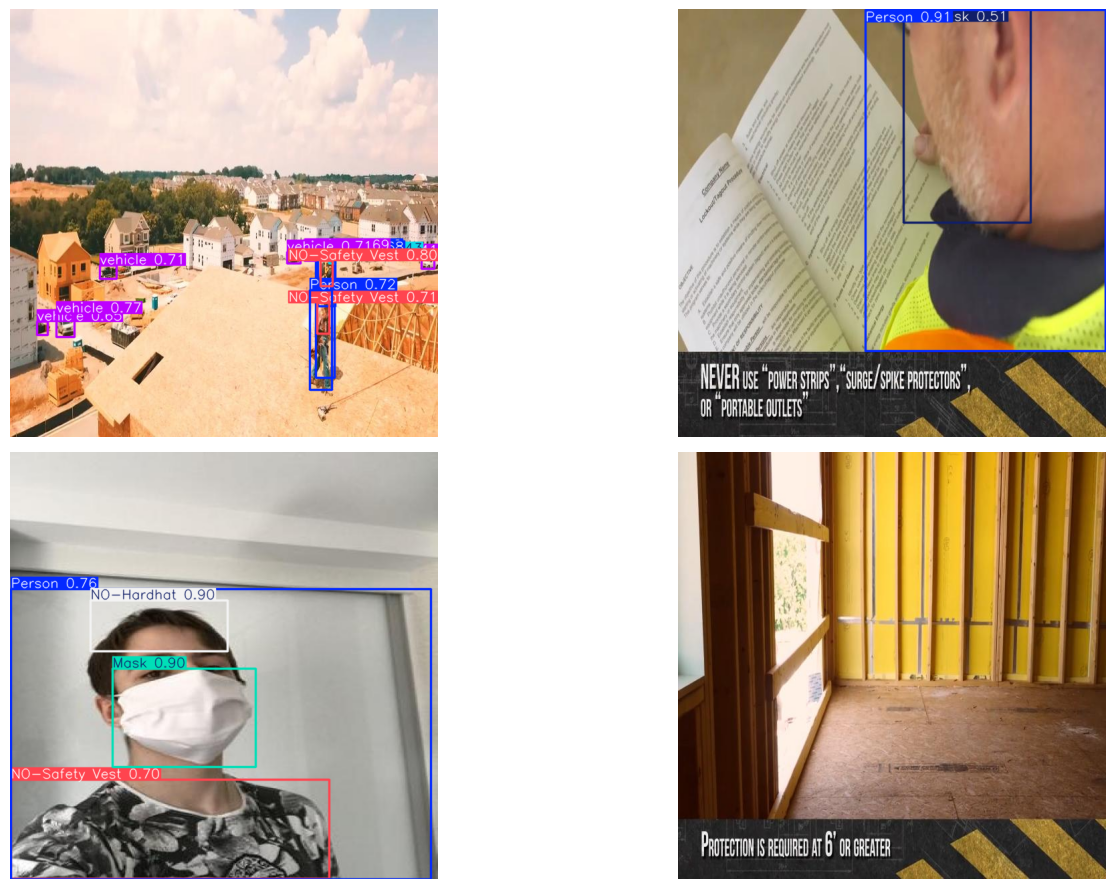

In [8]:
import random, glob
import matplotlib.pyplot as plt

test_imgs = glob.glob(str(DST / "test" / "images" / "*.*"))
sample = random.sample(test_imgs, min(4, len(test_imgs)))
preds = model.predict(sample, conf=0.4, verbose=False)

plt.figure(figsize=(16, 9))
for i, r in enumerate(preds):
    plt.subplot(2, 2, i + 1)
    plt.imshow(r.plot()[:, :, ::-1])   # BGR -> RGB
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Save the model

Copy `best.pt` somewhere you can grab it for the Streamlit/webcam demo. On
Colab, save to your mounted Drive so it survives the session.

In [9]:
# Training already writes everything to Drive (DRIVE_PROJECT), so your model and
# all Results figures are persisted at:
#   /content/drive/MyDrive/ppe_runs/ppe_yolov8s/
#     weights/best.pt, confusion_matrix.png, results.png, PR_curve.png, val_batch*_pred.jpg
import os
run = "/content/drive/MyDrive/ppe_runs/ppe_yolov8s"
print("Saved on Drive:", run, "->", "OK" if os.path.exists(run) else "NOT FOUND yet")

Saved on Drive: /content/drive/MyDrive/ppe_runs/ppe_yolov8s -> OK
